# Producing Graphs with plotnine
**Gary Mitchell**

**4/20/2021**

ggplot (from the ggplot2 package) has become the defacto graphing standard in data scientists using R.
ggplot provides a rich graphics *ecosystem* that provides flexible 2D and 3D graphics including scatterplots, line
graphs, bar/column charts, pie charts, area/surface charts, etc.

There are a couple of Python packages that provide ggplot-like capabilties and syntax. This very high-level tutorial
introduces plotnine, a Python package that provides a comprehensive ggplot implementation for Python. While the exact
syntax differs slightly from the original ggplot (it has to differ somewhat to account for syntax differences between
R and Python, it provides the same functionality in a consistent enough syntax such that R programmers will feel right
at home.

For those coming at this directly from Python (i.e. with no prior ggplot exposure), you may find it helpful
to learn more about ggplot in the R world. There is an enormous body of *how to* material and examples for ggplot
on the Internet (but most comes from the R world).

## ggplot fundamental concept

According to ggplot, a plot can be conceptually divided into different fundamental parts :

$$Plot = data + Aesthetics + Geometry.$$

ggplot implements this concept rather literally; with ggplot, we start by creating a plot with data and then *adding*
additional elements and customizations to the plot.

The principal components of every plot can be defined as follow:

- data -  is a data frame
- Aesthetics - used to indicate x and y variables. It can also be used to control the color, the size or the shape of points, the height of bars, etc…..
- Geometry  - corresponds to the type of graphics (histogram, box plot, line plot, density plot, dot plot, ….)

# Getting started with plotnine and ggplot

The only *real* way to get started is to begin creating graphs. Gaining familiarity here absolutely requires spending
time using/experiencing ggplot and learning how to do things. Initially, ggplot may not be intuitive. However, as you
continue to work with it, you will become more accustomed to the way the functionality is organized.

## Obtaining data and preparing the data

The first step in using ggplot is obtaining your data. In this example, we will use data that was obtained from an
online API providing up-to-date statistics on COVID-19 (e.g. new cases, new deaths, etc.). To simplify the example,
we are reading the data in from a .csv file that was previously created with the data obtained from the API.

We'll start by importing modules necessary for this example.

In [103]:
from plotnine.data import economics
#from plotnine import ggplot, aes, geom_line, geom_point
from plotnine import *
import pandas as pd
import numpy as np

Next, we'll read the data into a Pandas DataFrame, selecting only records for the state of Oregon and storing
the resulting data subset sorted by submission date. Finally, the submission date column is converted from a *string* value
that is hard to work with from a graphics viewpoint, to a Pandas date/time value which will facilitate our graphing
using plotnine.

In [104]:
covid_in = pd.read_csv('covidres_char_0_26820.csv')
covid = covid_in.loc[covid_in['state']=='OR',:].sort_values(by=['submission_date', 'state'],
                                                             ascending=True)
covid.loc[:, 'submission_date'] = covid.loc[:, 'submission_date'].astype('datetime64')

print(covid.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 447 entries, 10261 to 9899
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       447 non-null    int64         
 1   submission_date  447 non-null    datetime64[ns]
 2   state            447 non-null    object        
 3   tot_cases        447 non-null    int64         
 4   new_case         447 non-null    float64       
 5   pnew_case        359 non-null    float64       
 6   tot_death        447 non-null    int64         
 7   new_death        447 non-null    float64       
 8   pnew_death       359 non-null    float64       
 9   created_at       447 non-null    object        
 10  consent_cases    447 non-null    object        
 11  consent_deaths   447 non-null    object        
 12  conf_cases       359 non-null    float64       
 13  prob_cases       359 non-null    float64       
 14  conf_death       359 non-null    floa

We see from the info() output that we have 447 rows and 16 columns in our newly created DataFrame. Moreover, we can also
see that we have some missing values (e.g. pnew_case has only 359 non-null values while we have 447 total records in the
DataFrame).

Next, we *groupby* the submission date and aggregate the new_case values. This step is most likely not necessary,
as we would expect to have a single record per state per day. However, this way we need not be concerned about having
multiple records per day.

In [105]:
bydate = covid.loc[:,['submission_date','new_case']].groupby(by=['submission_date']).sum()
print(bydate)

                 new_case
submission_date          
2020-01-22            0.0
2020-01-23            0.0
2020-01-24            0.0
2020-01-25            0.0
2020-01-26            0.0
...                   ...
2021-04-08          667.0
2021-04-09          543.0
2021-04-10          747.0
2021-04-11          483.0
2021-04-12          282.0

[447 rows x 1 columns]


In the resulting dataframe, we have 447 rows and 1 column (the submission_date became the DataFrame's index and new_case
is the only column); since we have the same number of rows as before the aggregation,
we can conclude that the original data contained at most 1 record per day. Therefore, we
will use the *covid* DataFrame for the rest of this example.

If we wanted to continue using the *bydate* DataFrame, we would find that the submission_date is no longer a column
in the DataFrame; the groupby function used the unique submission_date values as the index of the grouped DataFrame.
Because we want the submission date as the horizontal variable for our plot, we would use the
Pandas.DataFrame.reset_index method to convert the current index,
submission_date, into a DataFrame column. The index will be replaced with a sequentially numbered index beginning at 0:

In [106]:
bydate.reset_index(inplace=True)
print(bydate)


    submission_date  new_case
0        2020-01-22       0.0
1        2020-01-23       0.0
2        2020-01-24       0.0
3        2020-01-25       0.0
4        2020-01-26       0.0
..              ...       ...
442      2021-04-08     667.0
443      2021-04-09     543.0
444      2021-04-10     747.0
445      2021-04-11     483.0
446      2021-04-12     282.0

[447 rows x 2 columns]


## Creating the plot with ggplot

We are finally ready to produce our plot. With ggplot, we can optionally save a plot object
for use later. This allows us to defer displaying a plot, add elements to the plot
in subsequent areas of our program, etc.

In the code fragment below, we create a new plot and assign the resulting ggplot object
to *orplot* (for Oregon plot).

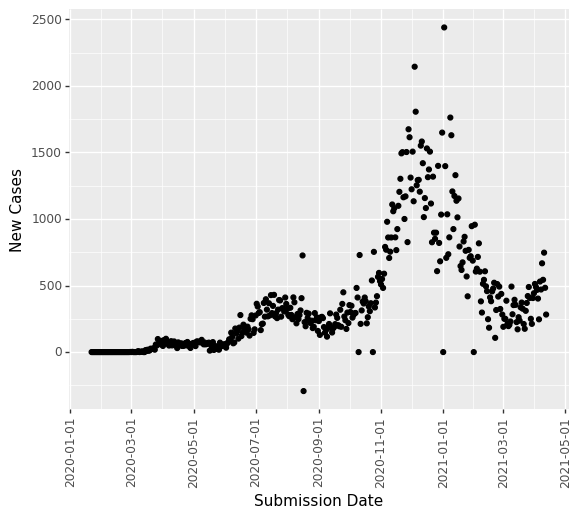

<ggplot: (-9223371905233704616)>

In [107]:
from plotnine import *

orplot = (
    ggplot(covid)  # What data to use
    + aes(x="submission_date", y="new_case")  # What variable to use
    + geom_point()  # Geometric object to use for drawing
    + theme(axis_text_x = element_text(angle = 90),
            plot_margin=0.25,
            figure_size=(10, 8))
    + xlab('Submission Date')
    + ylab('New Cases')
)

orplot

Let's break down the code. Notice that the RHS of the assignment is surrounded
with parenthesis. This is *not* part of the R ggplot syntax, but is required in
Python in order to use the *addition* metaphor for adding components to a plot.

The first statement within the parentheses is *ggplot(bydate)*. This creates an
empty plot that will use the bydate DataFrame. At this point, ggplot doesn't
know what to do with our dataframe, but knows that it will be using it.

The next statement, *+aes(...), adds a ggplot *aesthetic* to the plot. In this
case, the aesthetic is limited to identifying the horizontal ($x$) and vertical ($y$)
variables. A great deal more can be done with an aesthetic, including specifying a
color and/or size for plotting the points.

The third statement *adds* a *geom* to the plot; the geom tells ggplot that we
want to produce a scatter plot. A complete list of geoms ([geom reference](https://ggplot2.tidyverse.org/reference/))
can be found on the *tidyverse* website.

The fourth through sixth statements add a theme which customizes the formatting a little. In this case, we set the
figure_size to cover more of the document width, increase the plot margin size to accomodate our rotated axis labels,
and tell ggplot to rotate the x axis labels 90 degrees. All of these *thematic* instructions are to make the plot
more readable.

Next, we add explicit labels for our horizontal and vertical axes. If we do not explicitly specify axis labels,
ggplot will use the variable/column name as the default axis label.

The final statement simply displays the plot.

In the plot below, we make the plot more interesting by setting the color of the plotted dots based on
the number of new deaths. The graph now shows us that since November, even when the number of new COVID-19
cases in Oregon was up, the number of deaths was still relatively low.

What's *really* nice abou this is that ggplot does all of the work for us. We only need to modify the
aes to include the color specification, and ggplot takes care of everything including adding a legend.

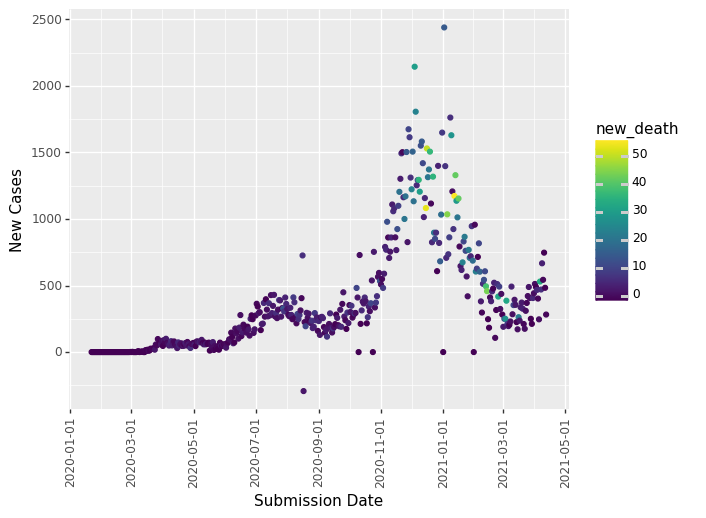

<ggplot: (-9223371905237255072)>

In [108]:

orplot = (
    ggplot(covid)  # What data to use
    + aes(x="submission_date", y="new_case", color='new_death')  # What variable to use
    + geom_point()  # Geometric object to use for drawing
    + theme(axis_text_x = element_text(angle = 90),
            plot_margin=0.25,
            figure_size=(10, 8))
    + xlab('Submission Date')
    + ylab('New Cases')
)

orplot
